# ARIMA and SARIMAX model investigation

The purpose of this script is to look into the standard ARIMA and SARIMAX models that are often cited in research as the baseline models for disease modeling

In [120]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
!pip install pmdarima
from pmdarima import auto_arima
from refactor_helpers.load_and_prep_data import load_and_prep_data
from pathlib import Path  
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [121]:
# Load and prepare the data
county_name: str = "Fresno"
file_type: str = "baseline"
data_path: Path = Path(f"../../data/{county_name.lower()}_agg_drought_{file_type}.csv")
tgt_variable: str = "VFRate"
X, y, feature_columns = load_and_prep_data(data_path, tgt_variable)

# Scale the features and target variable
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

# train/test split
split_index = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
y_train, y_test = y[:split_index], y[split_index:]  

# Auto ARIMA to find the best parameters
auto_model = auto_arima(y_train, exogenous=X_train, seasonal=True, m=12, trace=True, error_action='ignore', suppress_warnings=True, enforce_stationarity=False, enforce_invertibility=False)

Features: ['FIRE_Acres_Burned', 'PRECIP', 'WIND_EventCount', 'WIND_AvgMPH', 'WIND_RunMiles', 'AQI_PM25', 'AQI_PM10', 'EARTHQUAKE_Total', 'PESTICIDE_Total', 'RODENTICIDE_Total', 'Avg_Monthly_DSCI']
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=252.982, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=253.285, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=252.433, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=251.130, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=251.313, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=250.447, Time=0.02 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=252.129, Time=0.04 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=252.128, Time=0.06 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=inf, Time=0.49 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=252.432, Time=0.03 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC

In [122]:
print(auto_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                   69
Model:             SARIMAX(0, 1, 0)x(0, 0, [1], 12)   Log Likelihood                -122.313
Date:                              Sat, 18 Apr 2026   AIC                            248.627
Time:                                      18:30:11   BIC                            253.066
Sample:                                           0   HQIC                           250.386
                                               - 69                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12       0.2938      0.158      1.865      0.062      -0.015       0.603
sigma2         2.10

In [123]:
print("Best model parameters:", auto_model.order, auto_model.seasonal_order)

Best model parameters: (0, 1, 0) (0, 0, 1, 12)


In [124]:
sarimax_model = SARIMAX(y_train, exog=X_train, order=auto_model.order, seasonal_order=auto_model.seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
sarimax_results = sarimax_model.fit(disp=False)


/Users/dballen/.pyenv/versions/env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [125]:
print(sarimax_results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                   69
Model:             SARIMAX(0, 1, 0)x(0, 0, [1], 12)   Log Likelihood                 -91.439
Date:                              Sat, 18 Apr 2026   AIC                            208.879
Time:                                      18:30:11   BIC                            234.974
Sample:                                           0   HQIC                           218.970
                                               - 69                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.9735      0.731     -1.332      0.183      -2.406       0.459
x2            -1.28

In [126]:
train_preds = sarimax_results.predict(start=0, end=len(y_train)-1, exog=X_train)
test_preds = sarimax_results.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test) 

y_train_true = y_train.reshape(-1, 1).flatten()
y_train_pred = train_preds.reshape(-1, 1).flatten()
y_test_true = y_test.reshape(-1, 1).flatten()
y_test_pred = test_preds.reshape(-1, 1).flatten()
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Train RMSE: 1.8347
Test RMSE: 2.7808


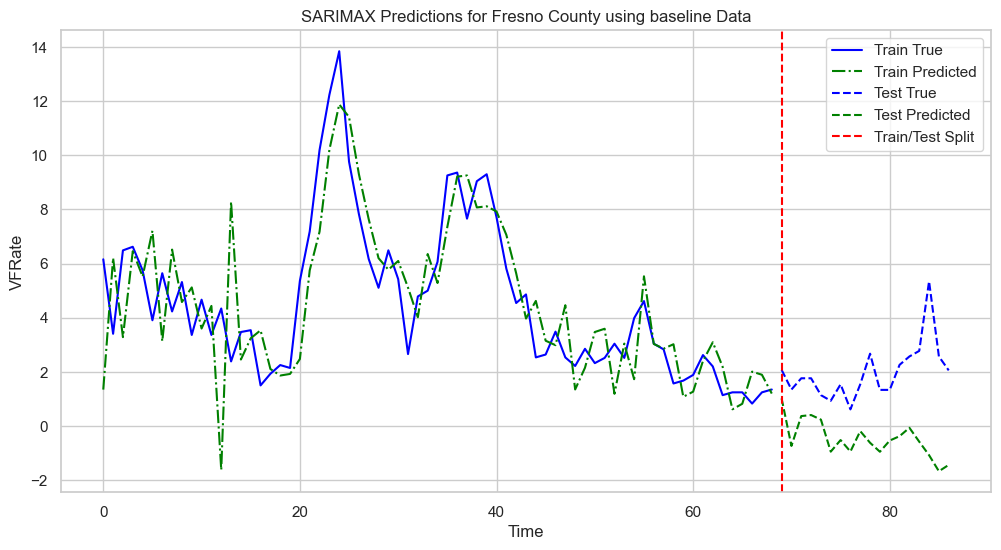

In [127]:
# redo with seaborn for better aesthetics
from matplotlib import lines


sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
plt.plot(y_train_true, label='Train True', color='blue')
plt.plot(y_train_pred, label='Train Predicted', color='green', linestyle='-.')
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test_true, label='Test True', color='blue', linestyle='--')
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test_pred, label='Test Predicted', color='green', linestyle='--') 
plt.axvline(x=len(y_train), color='red', linestyle='--', label='Train/Test Split')
plt.title(f"SARIMAX Predictions for {county_name} County using {file_type} Data")
plt.xlabel("Time")
plt.ylabel(f"{tgt_variable}")
plt.legend()
plt.show()